# 포트홀 탐지 - 실세계 적용

# 0. GPU메모리 확보를 위한 코드

In [1]:
import os
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'

import tensorflow as tf

# 메모리 성장 모드 — 필요한 만큼만 점진적으로 할당
gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

print("TF:", tf.__version__)
print("GPU:", gpus)

I0000 00:00:1780028908.820396   15406 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TF: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# 1. 모듈 불러오기

In [2]:
import os, random
import numpy as np
import tensorflow as tf
import koreanize_matplotlib
import matplotlib.pyplot as plt

# 2. 랜덤 시드 고정으로 재현성 확보하기

In [3]:
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# 3. 이미지 크기와 배치 사이즈 설정

In [4]:
# 일반적으로 딥러닝 학습시 224*224 사용(여러 유명 모델에서 사용한 이미지 크기)
IMG_HEIGHT = 224
IMG_WIDTH = 224

# 이미지가 컬러이기 때문에 배치사이즈 줄이자
BATCH_SIZE = 128 # 하이퍼파라미터 설정시 변경

- ResNet, VGG, MobileNet 등 거의 모든 사전학습 모델의 표준 입력 크기는 224 * 224

# 4-1. 데이터 불러오기

In [5]:
DATA_PATH = "/root/data/pothole"

TRAIN_DATA_PATH = DATA_PATH + "/images/train"
TEST_DATA_PATH = DATA_PATH + "/images/test"

print("학습 데이터 경로:", TRAIN_DATA_PATH)
print("테스트 데이터 경로:", TEST_DATA_PATH)


학습 데이터 경로: /root/data/pothole/images/train
테스트 데이터 경로: /root/data/pothole/images/test


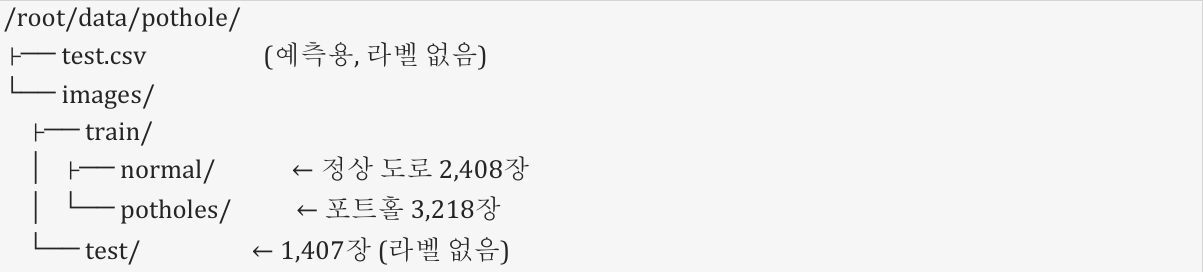

# 4-2. 학습 데이터셋 불러오기

In [6]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DATA_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='binary',
    color_mode="rgb" # 컬러이미지
)

Found 5626 files belonging to 2 classes.


Using 4501 files for training.


I0000 00:00:1780028925.076484   15406 gpu_process_state.cc:208] Using CUDA malloc Async allocator for GPU: 0
I0000 00:00:1780028925.078950   15406 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 68788 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:10:1c.0, compute capability: 8.0


- `label_mode='binary'`: 이진 분류이므로 라벨의 형태가 다름
>- normal 폴더의 이미지: 라벨 0.0
>- pothole 폴더의 이미지: 라벨 1.0
- 단일 sigmoid 출력과 모양을 맞추기 위해서임

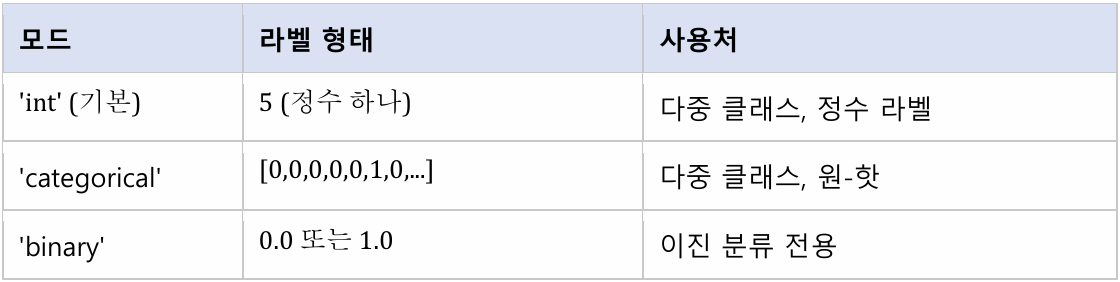
- `color_mode='rgb'`: 알파채널이 없는 이미지(3차원)

# 4-3. 검증 데이터셋 불러오기

In [7]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DATA_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='binary',
    color_mode="rgb" # 컬러이미지
)

Found 5626 files belonging to 2 classes.
Using 1125 files for validation.


# 4-4. 불러온 데이터셋 클래스 확인하기

In [8]:
# 클래스 이름 확인
class_names = train_ds.class_names
print("Class names:", class_names)

Class names: ['normal', 'potholes']


# 4-5. 데이터 전처리

In [9]:
# 클래스 이름 저장(map 적용 전에)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"클래스 개수: {num_classes}, 라벨: {class_names}")

클래스 개수: 2, 라벨: ['normal', 'potholes']


- 알파벳 순으로 정렬되기 때문에 `normal=0`, `pothole=1`임
- 이 순서가 뒤에서 매우 중요함(`class_weight`, sigmoid해석, `confusion matrix`라벨 모두 이 순서 기준)

In [10]:
# 데이터 정규화
normalization_layer = tf.keras.layers.Rescaling(1./255)

In [11]:
# 데이터셋에 정규화 적용
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

In [12]:
# 성능 최적화
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("데이터 전처리 완료")

데이터 전처리 완료


# 4-6. 학습 데이터셋 확인하기

W0000 00:00:1780028942.459337   16086 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


images dtype: <dtype: 'float32'>, min: 0.000, max: 1.000
labels dtype: <dtype: 'float32'>, shape: (128, 1)
labels 샘플 9개: [0. 1. 1. 1. 0. 0. 1. 1. 1.]
class_names: ['normal', 'potholes'] (len=2)


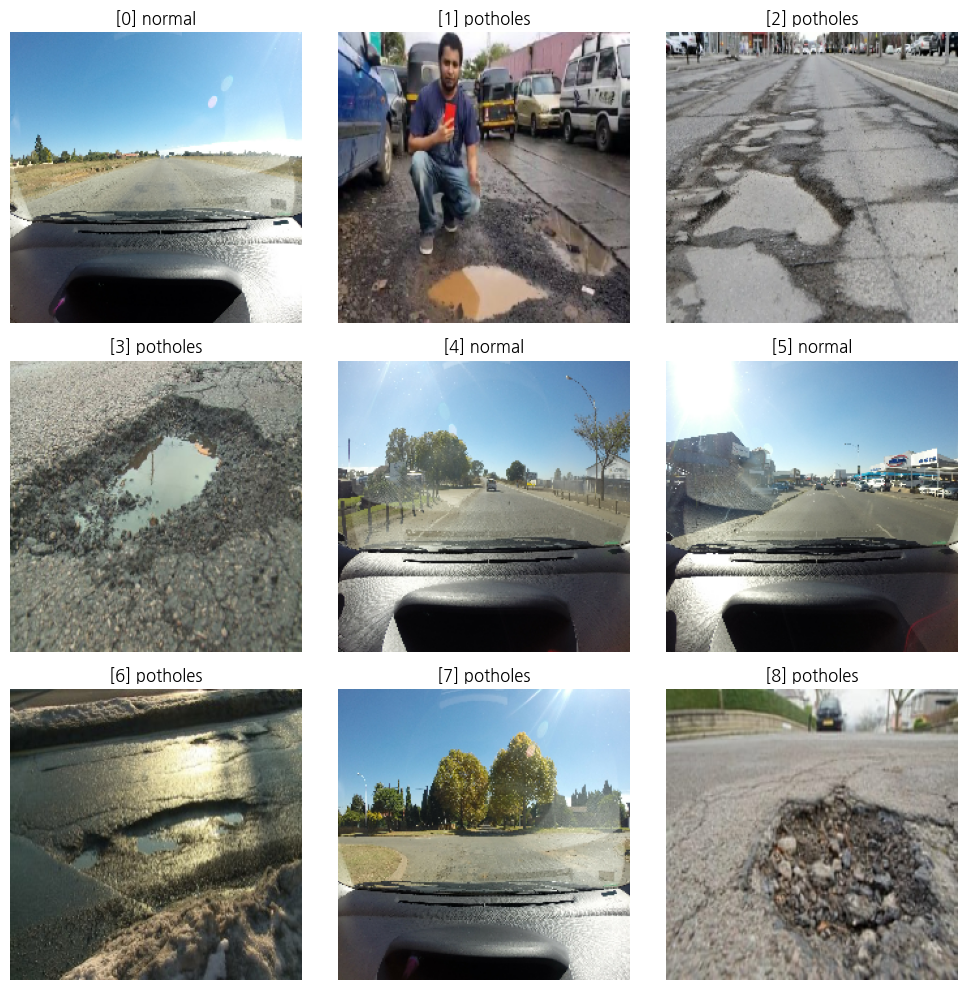

In [13]:
for images, labels in train_ds.take(1):
    print(f"images dtype: {images.dtype}, min: {images.numpy().min():.3f}, max: {images.numpy().max():.3f}")
    print(f"labels dtype: {labels.dtype}, shape: {labels.shape}")
    print(f"labels 샘플 9개: {labels[:9].numpy().flatten()}")
    print(f"class_names: {class_names} (len={len(class_names)})")

    plt.figure(figsize=(10, 10))
    for i in range(9):
        try:
            ax = plt.subplot(3, 3, i + 1)

            img = images[i].numpy()
            # 혹시 0~255 범위면 클리핑 방지
            if img.max() > 1.5:
                img = img.astype("uint8")

            plt.imshow(img)

            # 라벨이 (1,) shape이어도 안전하게 처리
            class_idx = int(labels[i].numpy().flatten()[0])
            plt.title(f"[{i}] {class_names[class_idx]}")
            plt.axis("off")
        except Exception as e:
            print(f"❌ i={i}에서 에러: {type(e).__name__}: {e}")
            break  # 어디서 멈췄는지 보이게

    plt.tight_layout()
    plt.show()
    break

# 4-7. 검증 데이터셋 확인하기

W0000 00:00:1780028948.754488   16196 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


images dtype: <dtype: 'float32'>, min: 0.000, max: 1.000
labels dtype: <dtype: 'float32'>, shape: (128, 1)
labels 샘플 9개: [0. 1. 0. 1. 1. 0. 0. 1. 1.]
class_names: ['normal', 'potholes'] (len=2)


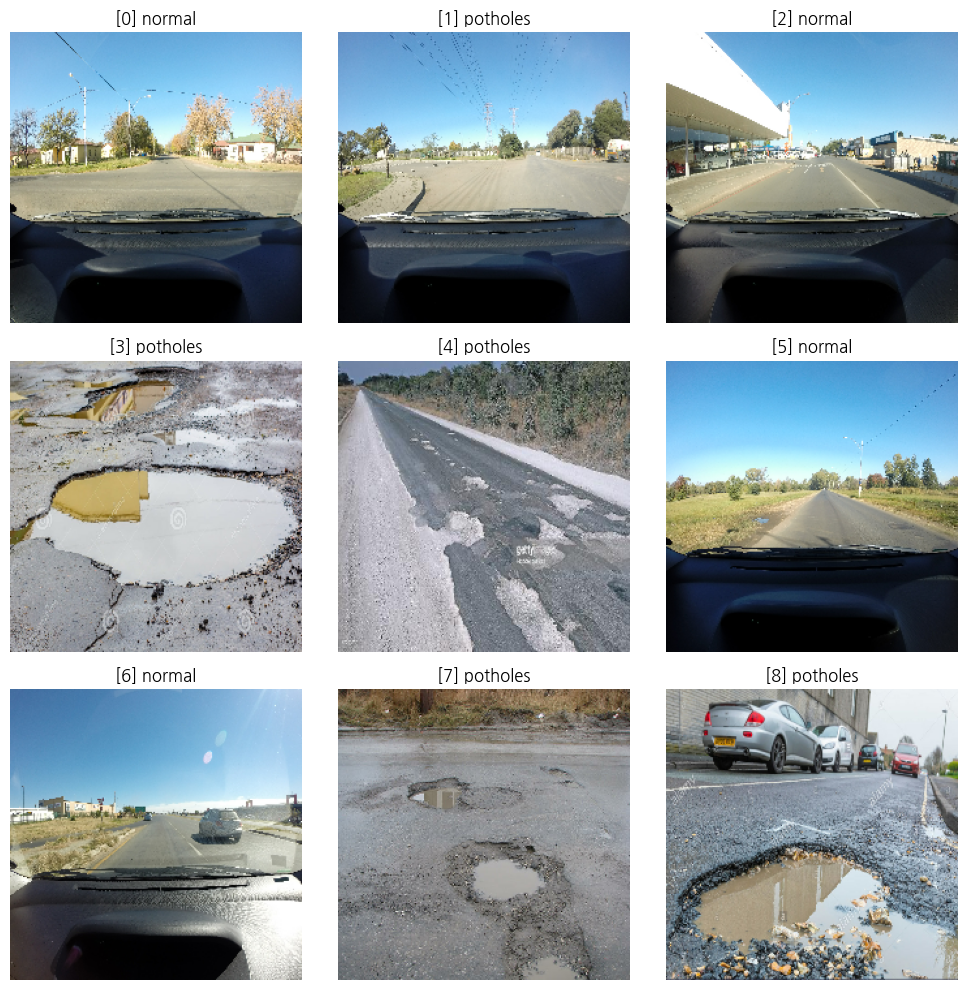

In [14]:
for images, labels in val_ds.take(1):
    print(f"images dtype: {images.dtype}, min: {images.numpy().min():.3f}, max: {images.numpy().max():.3f}")
    print(f"labels dtype: {labels.dtype}, shape: {labels.shape}")
    print(f"labels 샘플 9개: {labels[:9].numpy().flatten()}")
    print(f"class_names: {class_names} (len={len(class_names)})")

    plt.figure(figsize=(10, 10))
    for i in range(9):
        try:
            ax = plt.subplot(3, 3, i + 1)

            img = images[i].numpy()
            # 혹시 0~255 범위면 클리핑 방지
            if img.max() > 1.5:
                img = img.astype("uint8")

            plt.imshow(img)

            # 라벨이 (1,) shape이어도 안전하게 처리
            class_idx = int(labels[i].numpy().flatten()[0])
            plt.title(f"[{i}] {class_names[class_idx]}")
            plt.axis("off")
        except Exception as e:
            print(f"❌ i={i}에서 에러: {type(e).__name__}: {e}")
            break  # 어디서 멈췄는지 보이게

    plt.tight_layout()
    plt.show()
    break

# 5. 데이터 증강 설정

In [15]:
data_aug = tf.keras.Sequential([
    # 1. 기하학적 변환 (형태 다양화)
    # 포트홀은 위아래/좌우가 뒤집혀도 포트홀이므로, 상하좌우 모두 반전 허용
    tf.keras.layers.RandomFlip("horizontal", seed=SEED),

    # 회전 (약 20% 범위), 빈 공간은 주변 픽셀로 채움(nearest)
    tf.keras.layers.RandomRotation(0.05, fill_mode='nearest', seed=SEED),

    # 확대/축소 (약 20% 범위)
    tf.keras.layers.RandomZoom(0.1, seed=SEED),

    # 위치 이동 (상하좌우 10% 정도 움직여서 포트홀이 구석에 있는 경우 대비)
    tf.keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1, seed=SEED),

    # 2. 광학적 변환 (날씨/조명 다양화 - 실사 이미지에 매우 중요!)
    # 밝기 조절 (그림자나 햇빛 대응)
    tf.keras.layers.RandomBrightness(factor=0.15, seed=SEED),

    # 대비 조절 (아스팔트 색상이나 마모도 차이 대응)
    tf.keras.layers.RandomContrast(factor=0.15, seed=SEED),
])

- 기하학적 변환 4종
>- `RandomFlip("horizontal")`: 이번엔 사용함. 포트홀은 좌우 대칭 의미가 없어서 안전. CoMNIST 에서는 b↔d 문제로 주석 처리했지만.
>- `RandomRotation(0.05)`: ±5% 즉 ±18 도 정도. CoMNIST(0.2)보다 보수적. 도로 사진은 너무 많이 돌리면 비현실적.
>- `RandomZoom(0.1)`: ±10%. 카메라 거리 변화 시뮬레이션.
>- `RandomTranslation(0.1, 0.1)`: MNIST 에서 못 풀었던 그 이동 문제의 해결. 포트홀이 화면 중앙이 아닌 구석에 있어도 인식.
- 광학적 변환 2종 [실사 사진 특화]
>- `RandomBrightness(0.15)`: 밝기 ±15%. 한낮·새벽·그림자 대응.
>- `RandomContrast(0.15)`: 대비 ±15%. 마모된 아스팔트 vs 새 도로 등 다양한 텍스처 대응.

- 광학적 증강이 실세계 적용에서 결정적인 차이를 만듬

# 6-1. CNN 모델 구조 설정

In [16]:
inputs = tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))

x = data_aug(inputs)

# --- Block 1 ---
x = tf.keras.layers.Conv2D(32, (3, 3), padding="same")(x)
x = tf.keras.layers.ReLU()(x)
x = tf.keras.layers.MaxPooling2D((2, 2))(x)

# --- Block 2 ---
x = tf.keras.layers.Conv2D(64, (3, 3), padding="same")(x)
x = tf.keras.layers.ReLU()(x)
x = tf.keras.layers.MaxPooling2D((2, 2))(x)

# --- Block 3 ---
x = tf.keras.layers.Conv2D(128, (3, 3), padding="same")(x)
x = tf.keras.layers.ReLU()(x)
x = tf.keras.layers.MaxPooling2D((2, 2))(x)

# --- Block 4 ---
x = tf.keras.layers.Conv2D(256, (3, 3), padding="same")(x)
x = tf.keras.layers.ReLU()(x)
x = tf.keras.layers.MaxPooling2D((2, 2))(x)

# --- 분류기 ---
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(128)(x)
x = tf.keras.layers.ReLU()(x)

# 출력층: 시그모이드를 사용하기 위해 1개로 설정
# 이진분류이므로 시그모이드 함수 사용 -> threshold는 0.5 사용
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

# 모델 생성
model = tf.keras.Model(inputs, outputs, name="pothole_cnn_baseline")

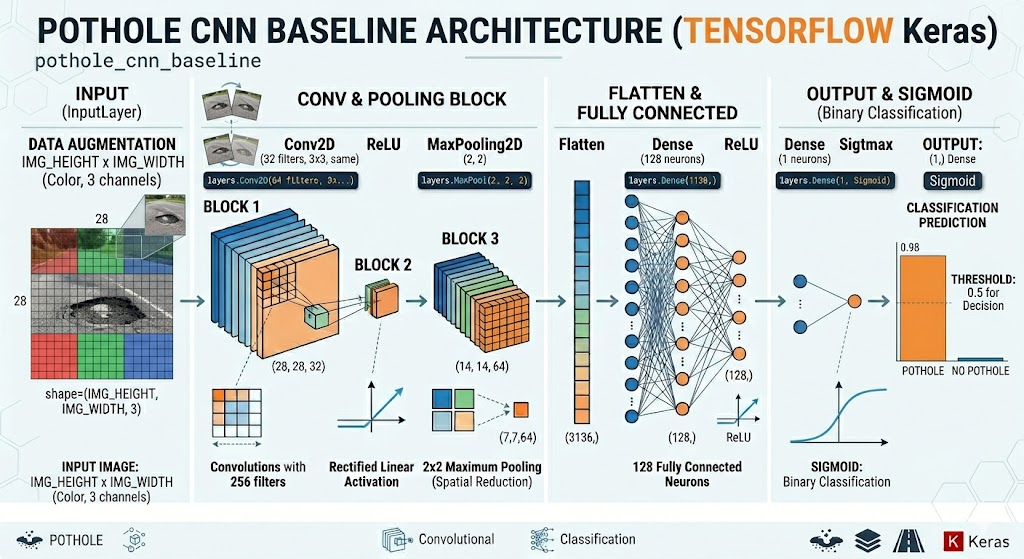

- CoMNIST 대비 발전된 점
>- 4개 Conv 블록 (CoMNIST는 2개)
>>- 필터 수가 32 → 64 → 128 → 256으로 두 배씩 증가.
>>- 왜 깊이 갈수록 채널을 늘리나?
>>>- 풀링으로 가로·세로는 줄어들지만(공간 압축)
>>>- 필터 수를 늘려서 채널 방향의 표현력을 보강(특징 다양성 확보)
>>>- "공간 → 추상화"로 정보가 흘러가는 CNN의 표준 패턴
>- 3채널 입력 shape=(224, 224, 3)
>>- RGB 컬러. Conv2D가 R, G, B를 모두 보면서 색상 패턴까지 학습.
>- 출력층이 Dense(1, activation="sigmoid") [가장 큰 변화]
>> 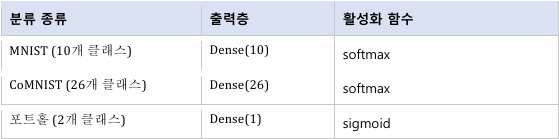
>>- 이진분류에서는 한 클래스의 확률만 알면 다른 클래스 확률은 자동으로 계산되기 때문
>>>- sigmoid 출력이 0.7 → "포트홀일 확률 70%" → 자동으로 "정상일 확률 30%"
>>>- 임계값 0.5를 넘으면 포트홀(1), 아니면 정상(0)으로 판단

# 6-2. CNN 모델 컴파일

In [17]:
# learning_rate 조정을 위해
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

# 지표 정의(이름을 줘야 monitor에 쓰기 편함)
auc = tf.keras.metrics.AUC(name="auc")
prec = tf.keras.metrics.Precision(name="precision")
rec = tf.keras.metrics.Recall(name="recall")

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=["accuracy", prec, rec, auc],
)

- 명시적 `learning rate` 설정
>- `Adam(learning_rate=0.0001)` — 기본값(0.001)보다 10배 작게. 작은 보폭으로 학습.
>- 이유:
>>- 데이터 증강이 강해서 한 번에 크게 움직이면 발산 위험
>>- 큰 모델은 보통 낮은 학습률에서 안정적
>>- 다음 셀의 ReduceLROnPlateau가 자동으로 더 줄여주기도 함
- `loss='binary_crossentropy'`
> 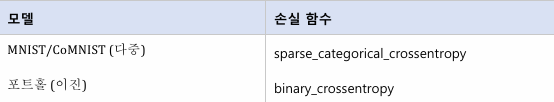
>- sigmoid 출력과 짝을 이루는 손실 함수. 이걸 잘못 쓰면 학습이 안됨.
- 4개의 평가지표
>- accuracy: 전체 맞춤 비율
>- precision: "포트홀이다!" 외친 것 중 진짜 포트홀 비율
>- recall: 실제 포트홀 중 모델이 찾아낸 비율 — 도로 안전에서 가장 중요
>- auc: 변별력 종합 점수
- `name="..."`을 지정하는 이유
>- 다음 셀의 콜백에서 `monitor="val_auc"`처럼 이름으로 참조하기 위
해서.
>- 이름을 안 주면 자동 이름(precision_1 등)이 부여돼서 추적이 까다로워짐

# 6-3. CNN 모델 요약

In [18]:
model.summary()

Model: "pothole_cnn_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,422,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,811,201 (25.98 MB)

 Trainable params: 6,811,201 (25.98 MB)

 Non-trainable params: 0 (0.00 B)

- 각 Conv층 파라미터 계산
>- Conv2D(32) — 입력 채널 3 (RGB)
>>- 필터 1개당 가중치: 3 × 3 × 3 = 27개
>>- 필터 1개당 편향: 1개 → 합 28개
>>- 32개 필터: 28 × 32 = 896개
>- Conv2D(64) — 입력 채널 32
>>- 필터 1개당 가중치: 3 × 3 × 32 = 288개
>>- 필터 1개당 편향: 1개 → 합 289개
>>- 64개 필터: 289 × 64 = 18,496개
>- Conv2D(128) — 입력 채널 64
>>- 필터 1개당 가중치: 3 × 3 × 64 = 576개
>>- 필터 1개당 편향: 1개 → 합 577개
>>- 128개 필터: 577 × 128 = 73,856개
>- Conv2D(256) — 입력 채널 128
>>- 필터 1개당 가중치: 3 × 3 × 128 = 1,152개
>>- 필터 1개당 편향: 1개 → 합 1,153개
>>- 256개 필터: 1,153 × 256 = 295,168개

- MaxPool 출력 크기 추적
>- 입력 224×224에서 시작해서 4번의 (2,2) 풀링:
>>- 224 → 112 → 56 → 28 → 14
>- 마지막 feature map: (14, 14, 256). Flatten 결과: 14 × 14 × 256 = 50,176

- Dense(128) — 분류기의 큰 부분
>- 가중치: 50,176 × 128 = 6,422,528 개
>- 편향: 128개
>- 합계: 6,422,656 개

- Dense(1) — 마지막 출력
>- 가중치: 128 × 1 = 128개
>- 편향: 1개
>- 합계: 129개

- 총 합산: 896 + 18,496 + 73,856 + 295,168 + 6,422,656 + 129 = 6,811,201개

# 6-4. Early stopping 설정

In [19]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        patience=10,
        restore_best_weights=True,
        verbose=1,
        mode="max"
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        factor=0.2,
        patience=5,
        min_lr=1e-6,
        verbose=1,
        mode="max"
    )
]

- CoMNIST와 달리 콜백이 2개로 늘어남.
- `val_loss`가 아닌 `val_auc`로 변경
- `EarlyStopping`: 인자 변경
>- `monitor="val_auc"`: AUC 가 변별력의 종합 지표라 가장 의미 있음. Recall이나 Precision 은 한쪽으로 치우칠 수 있어서 AUC가 더 안정적.
>- `mode="max"`: AUC 는 클수록 좋은 지표. loss는 작을수록 좋아서 mode='min'이 기본인데, accuracy/AUC/precision/recall 은 명시적으로 'max'를 지정해야 함. 이걸 빼먹으면 정반대로 동작해서 학습이 일찍 끝남.
>- `patience=10`: AUC 는 변동이 좀 있어서 CoMNIST의 5보다 여유 둠.
- `ReduceLROnPlateau`: 새롭게 추가
>- 학습률을 자동으로 줄여주는 콜백. "학습이 정체되면 보폭을 줄여서 미세 조정" 하는 전략.
>>- `factor=0.2`: 정체 감지 시 학습률을 1/5로 줄임 (0.0001 → 0.00002)
>>- `patience=5`: 5 epoch 동안 val_auc 개선 없으면 발동
>>- `min_lr=1e-6`: 너무 작아지지 않도록 하한선

- 산 정상에서 내려오다가 골짜기 근처에 왔는데 더 안내려가면 "보폭을 작게 해서 정밀하게 더 내려가자"는 의미. 모델이 미세하게 더 좋아질 여지를 짜내는 효과

# 7. 학습하기

In [20]:
import time
import datetime

start_time = time.time()

# --- 클래스 매핑 확인 (안전장치) ---
# 0번이 Normal이 맞는지 꼭 확인하세요!
print(f"Class 0: {class_names[0]}, Class 1: {class_names[1]}")

# --- 학습 코드 -------------
# 포트홀 : 정상 = 4025 : 3010
# 비정상적으로 포트홀의 이미지가 1.33배 많음
# 따라서 정상 데이터에 1.33배 가중치를 줘야지 모델이 그냥 찍지 않음
class_weight = {
    0: 1.33, # normal에 1.33배 가중치
    1: 1.0  # pothole는 그대로 기준점
}
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    # batch_size=BATCH_SIZE, # train_ds에 이미 포함되어 있기 때문에 삭제
    callbacks=callbacks,
    class_weight=class_weight, # 가중치 주고 학습하기
    verbose=1
)
# -------------------------
end_time = time.time()
execution_time = end_time - start_time

# 시:분:초 형태로 자동 변환
str_time = str(datetime.timedelta(seconds=execution_time))
print(f"총 학습 소요 시간: {str_time}")

Class 0: normal, Class 1: potholes
Epoch 1/100


I0000 00:00:1780028994.080796   15834 cuda_dnn.cc:461] Loaded cuDNN version 92200


36/36 ━━━━━━━━━━━━━━━━━━━━ 29s 197ms/step - accuracy: 0.4741 - auc: 0.4999 - loss: 0.8481 - precision: 0.5685 - recall: 0.2871 - val_accuracy: 0.7813 - val_auc: 0.8425 - val_loss: 0.6889 - val_precision: 0.9633 - val_recall: 0.6607 - learning_rate: 1.0000e-04
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.4763 - auc: 0.5091 - loss: 0.7947 - precision: 0.5881 - recall: 0.2442 - val_accuracy: 0.5884 - val_auc: 0.8597 - val_loss: 0.6882 - val_precision: 0.9732 - val_recall: 0.3230 - learning_rate: 1.0000e-04
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.4595 - auc: 0.5391 - loss: 0.7911 - precision: 0.6361 - recall: 0.1011 - val_accuracy: 0.7529 - val_auc: 0.8651 - val_loss: 0.6783 - val_precision: 0.9584 - val_recall: 0.6148 - learning_rate: 1.0000e-04
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.5117 - auc: 0.5794 - loss: 0.7835 - precision: 0.6260 - recall: 0.3370 - val_accuracy: 0.7227 - val_auc: 0.8596 - val_loss: 0.6461 - v

- `class_weight`: 데이터 불균형 처리
>- 포트홀은 4,025장, 정상은 3,010장으로 비율이 약 1.33:1로 한쪽이 많음.
>- 이 상태로 학습하면 모델이 "전부 포트홀이라고 찍어버리면 어차피 60% 가까이 맞으니까.."하는 게으른 전략을 학습할 수 있음
>- 해결책: 수가 적은 쪽(정상)의 손실에 1.33배 가중치를 줘서 모델이 무시하지 못하게 함.
- `epoch=100`
>- EarlyStopping이 알아서 적당한 시점에 멈춰주기 때문에 상한선의 의미만 있음.

# 8. 모델 평가

In [21]:
loss, acc, precision, recall, auc = model.evaluate(val_ds, verbose=0)

print(f"Loss:      {loss:.4f}")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"AUC:       {auc:.4f}")

Loss:      0.6783
Accuracy:  0.7529
Precision: 0.9584
Recall:    0.6148
AUC:       0.8651


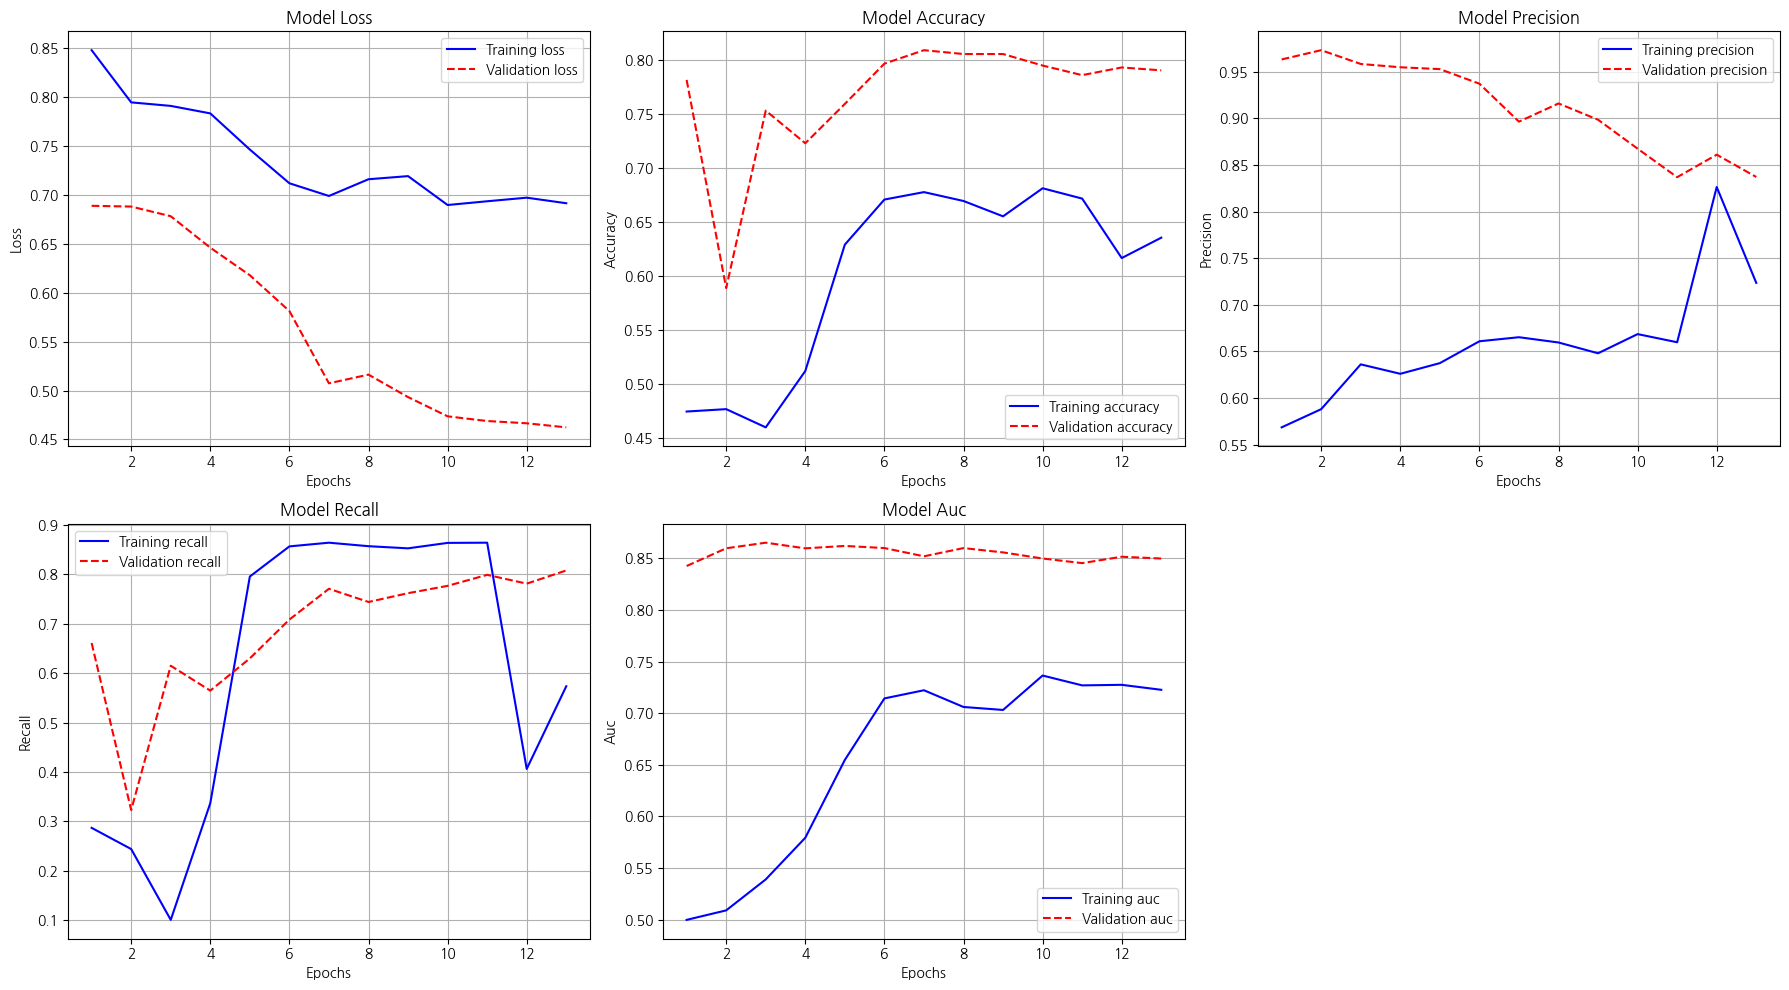

In [22]:
import matplotlib.pyplot as plt

def plot_history(history):
    # 확인할 지표 리스트 (compile 시 설정한 이름과 일치해야 함)
    metrics = ['loss', 'accuracy', 'precision', 'recall', 'auc']

    # 그래프 크기 설정 (2행 3열)
    plt.figure(figsize=(18, 10))

    for i, metric in enumerate(metrics):
        plt.subplot(2, 3, i + 1) # 2행 3열의 i+1번째 칸

        train_values = history.history[metric]
        val_values = history.history[f'val_{metric}']
        epochs = range(1, len(train_values) + 1)

        plt.plot(epochs, train_values, 'b-', label=f'Training {metric}')
        plt.plot(epochs, val_values, 'r--', label=f'Validation {metric}')

        plt.title(f'Model {metric.capitalize()}')
        plt.xlabel('Epochs')
        plt.ylabel(metric.capitalize())
        plt.legend()
        plt.grid(True)

    plt.tight_layout()
    plt.show()

# 그래프 출력
plot_history(history)

- 해석 포인트
>- Loss는 둘 다 내려가야 함. Train loss < Val loss이면 과적합 시작.
>- Accuracy 는 둘 다 올라가야 함.
>- Precision 은 모델이 신중한지(높을수록 신중)
>- Recall 은 놓치지 않는지 (포트홀 안전에서 핵심)
>- AUC는 전체적 변별력 (0.85+면 양호)
- Val_acc가 Train_acc보다 높은이유
>- 데이터 증강 + Dropout 같은 정규화 효과 때문에 학습 중에는 모델이 "어려운 문제"를 풀고 있기 때문

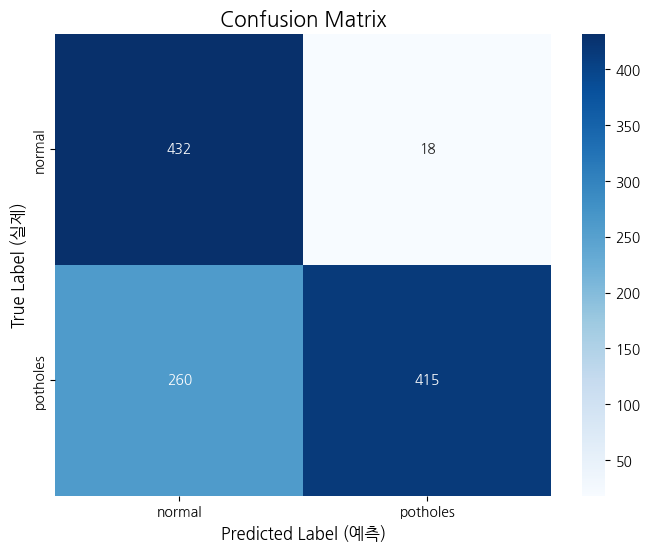


--- 상세 결과 ---
✅ 실제 정상인데 정상으로 맞춤 (TN): 432
🚨 실제 정상인데 포트홀로 오보 (FP): 18
⚠️ 실제 포트홀인데 정상으로 놓침 (FN): 260
🔥 실제 포트홀을 포트홀로 맞춤 (TP): 415


In [23]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def display_confusion_matrix(model, dataset, class_names, threshold):
    all_labels = []
    all_preds = []

    # 1. 데이터셋에서 실제 라벨과 예측값 수집
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        all_labels.extend(labels.numpy())
        all_preds.extend(preds)

    all_labels = np.array(all_labels).flatten()
    all_preds = np.array(all_preds).flatten()

    # 2. 임계값(0.5)을 기준으로 0 또는 1로 변환
    all_preds_binary = (all_preds > threshold).astype(int)

    # 3. 혼동 행렬 계산
    cm = confusion_matrix(all_labels, all_preds_binary)

    # 4. 시각화
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)

    plt.title('Confusion Matrix', fontsize=15)
    plt.xlabel('Predicted Label (예측)', fontsize=12)
    plt.ylabel('True Label (실제)', fontsize=12)
    plt.show()

    # 간단한 요약 출력
    tn, fp, fn, tp = cm.ravel()
    print(f"\n--- 상세 결과 ---")
    print(f"✅ 실제 정상인데 정상으로 맞춤 (TN): {tn}")
    print(f"🚨 실제 정상인데 포트홀로 오보 (FP): {fp}")
    print(f"⚠️ 실제 포트홀인데 정상으로 놓침 (FN): {fn}")
    print(f"🔥 실제 포트홀을 포트홀로 맞춤 (TP): {tp}")

# 실행 (학습 완료 후 호출)
display_confusion_matrix(model, val_ds, class_names, 0.50)

- 혼동 행렬
> 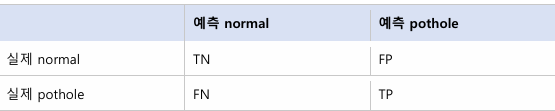
>- 코드 동작 흐름
>>- 전체 검증셋 순회: 모든 이미지 예측 (sigmoid 확률값)
>>- 임계값 0.5로 이진화: (preds > 0.5) → 0 또는 1
>>- confusion_matrix(실제, 예측): sklearn 이 2×2 행렬 계산
>>- sns.heatmap: 파란색 그라데이션 히트맵, 숫자 표시
>>- cm.ravel(): 2×2 를 풀어서 (TN, FP, FN, TP)로 분해
>- 도로 안전 측면에서는 FN을 줄이는게 최우선

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


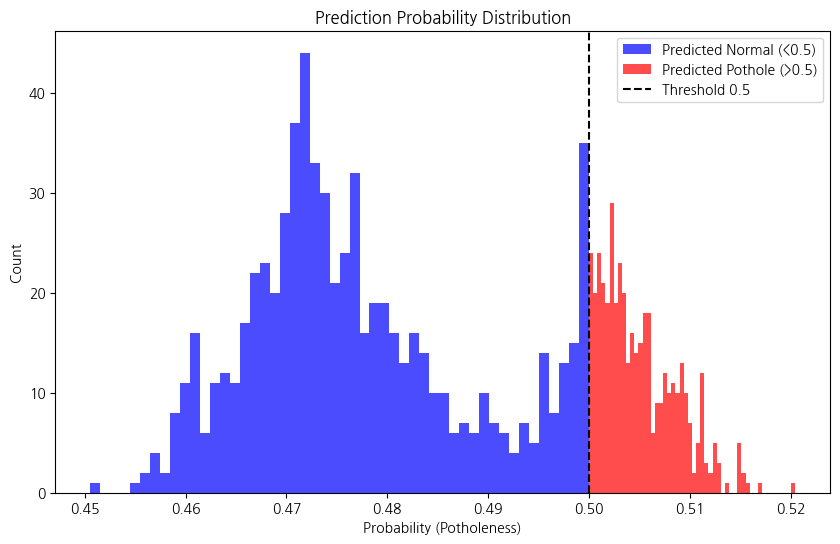

In [28]:
# 히스토그램

# 1. 검증 데이터셋의 예측 확률값 가져오기
predictions = model.predict(val_ds)

# 2. 확률값 분포 히스토그램 그리기
plt.figure(figsize=(10, 6))
plt.hist(predictions[predictions <= 0.5], bins=50, alpha=0.7, color='blue', label='Predicted Normal (<0.5)')
plt.hist(predictions[predictions > 0.5], bins=50, alpha=0.7, color='red', label='Predicted Pothole (>0.5)')

# 0.3과 0.5 기준선 표시
plt.axvline(x=0.5, color='black', linestyle='--', label='Threshold 0.5')
#plt.axvline(x=0.3, color='green', linestyle='--', label='Threshold 0.3')

#plt.xlim(0, 1)

plt.title('Prediction Probability Distribution')
plt.xlabel('Probability (Potholeness)')
plt.ylabel('Count')
plt.legend()
plt.show()

- 판단 기준(임계값)을 정하자

In [25]:
import pandas as pd
import tensorflow as tf
import os
import numpy as np

# 1. 설정 및 준비
IMG_HEIGHT = 224
IMG_WIDTH = 224
base_path = '/root/data/pothole'  # 기존 다운로드 경로 사용

# test.csv 로드
test_df = pd.read_csv(os.path.join(base_path, 'test.csv'))

# 클래스 이름 (학습 시 0: normal, 1: potholes 순서였음)
class_names = ['normal', 'potholes']

# 2. [핵심] 안전한 이미지 로드 제너레이터 (에러 방지)
def test_image_generator():
    """
    이미지를 하나씩 읽어서 반환하되,
    깨진 파일이 있으면 '검은색 이미지'를 대신 반환하여
    전체 개수와 순서를 지킴
    """
    for fname in test_df['filename']:
        # 경로 생성 (혹시 images 폴더가 없으면 바로 path에서 찾음)
        file_path = os.path.join(base_path, 'images', fname)
        if not os.path.exists(file_path):
             file_path = os.path.join(base_path, fname)

        try:
            # 이미지 읽기 & 전처리
            img_raw = tf.io.read_file(file_path)
            img = tf.io.decode_image(img_raw, channels=3, expand_animations=False)
            img = tf.image.resize(img, [IMG_HEIGHT, IMG_WIDTH])
            img = tf.cast(img, tf.float32) / 255.0
            yield img

        except Exception as e:
            # 🚨 에러 발생 시 로그 출력 후 '검은색 빈 이미지' 대체
            print(f"⚠️ 손상된 파일 발견 (0값 대체): {fname}")
            yield tf.zeros([IMG_HEIGHT, IMG_WIDTH, 3], dtype=tf.float32)

# 3. 데이터셋 만들기 (from_generator 사용)
test_ds = tf.data.Dataset.from_generator(
    test_image_generator,
    output_signature=tf.TensorSpec(shape=(IMG_HEIGHT, IMG_WIDTH, 3), dtype=tf.float32)
)

# 배치 설정 (배치 크기 32)
test_ds = test_ds.batch(32).prefetch(tf.data.AUTOTUNE)

# 4. 예측 수행
print(f"🚀 테스트 데이터 {len(test_df)}개 예측 시작...")
predictions = model.predict(test_ds, verbose=1)

# 5. 결과 변환 (확률 -> 라벨)
threshold = 0.5
predicted_indices = (predictions > threshold).astype(int).flatten()
predicted_labels = [class_names[i] for i in predicted_indices]

# 6. submission.csv 저장
submission = pd.DataFrame({
    'filename': test_df['filename'],
    'label': predicted_labels
})

save_filename = 'pothole_complete.csv'
submission.to_csv(save_filename, index=False)

print(f"\n✅ {save_filename} 파일 저장 완료!")
print(submission.head())

🚀 테스트 데이터 1407개 예측 시작...


I0000 00:00:1780029058.695700   15406 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


44/44 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step

✅ pothole_complete.csv 파일 저장 완료!
                                            filename     label
0          test/potholes_00000_asdfsdfsdfasdf102.jpg  potholes
1                test/potholes_00001_asdf258_(1).jpg  potholes
2                     test/normal_00002_G0027171.JPG    normal
3                   test/potholes_00003_G0088293.JPG    normal
4  test/potholes_00004_asdf92.5343561_061219-ewn-...  potholes


/root/venv/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
